# 03. 회귀 모델 비교, 평가와 오류 분석
후보 학습과 중첩 그룹 튜닝은 `python -m src.train`으로 재현한다.
이 노트북은 실제 저장 결과와 선택 기록을 읽고, 저장 모델을 다시 불러와 외부 예측을 재계산한다.
외부 평가 결과로 모델을 교체하지 않는다.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import display, Image, Markdown
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
def show_plot(name):
    display(Image(filename=str(ROOT / f'results/figures/{name}.png')))


## 개발 데이터의 후보 비교

,model,family,feature_set,n_features,CV MAPE mean (%),CV MAPE std (%),OOF pooled MAPE (%),OOF MAE (cycles)
0,ElasticNet / discharge,ElasticNet,discharge,4,7.7197,2.5643,7.6320,58.5070
1,ElasticNet / current,ElasticNet,current,10,8.2354,3.7596,8.3563,63.9282
2,Ridge / discharge,Ridge,discharge,4,8.2518,2.0679,8.1701,63.1200
3,Ridge / current,Ridge,current,10,8.3509,1.2663,8.4219,65.0090
4,SVR / variance,SVR,variance,1,8.3758,1.4888,8.3389,65.4028
5,SVR / discharge,SVR,discharge,4,8.8691,5.3155,8.6065,63.6732
6,Ridge / variance,Ridge,variance,1,8.9270,2.0123,8.8056,69.5852
7,ElasticNet / state,ElasticNet,state,8,9.0031,2.2541,8.9554,68.4332
8,Variance linear,Linear,variance,1,9.0257,2.0979,8.9018,70.3812
9,RandomForest / discharge,RandomForest,discharge,4,9.4925,3.7879,9.2459,70.7389


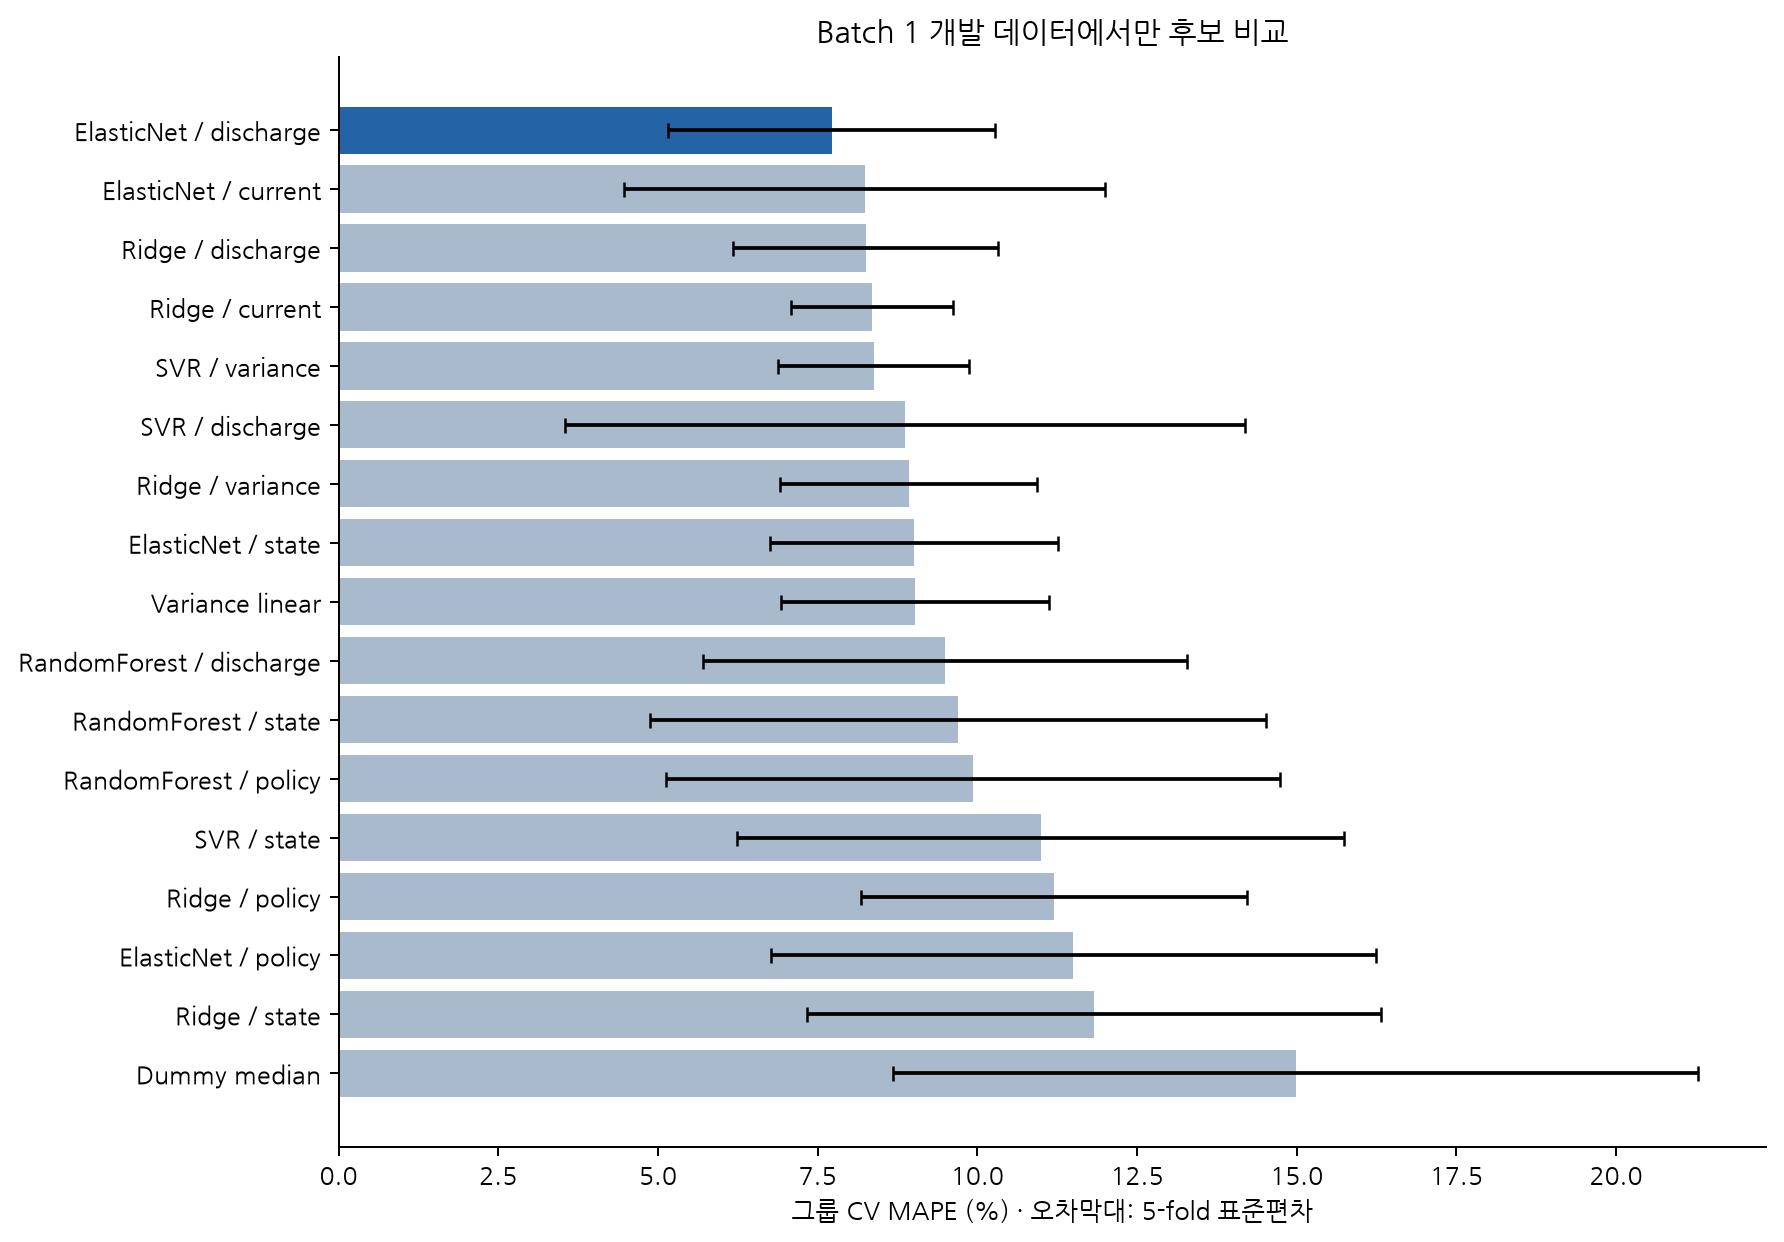

In [2]:
comparison = pd.read_csv(ROOT/'results/cv_comparison.csv')
display(comparison)
show_plot('10_cv_candidates')

## 최종 선택과 하이퍼파라미터

In [3]:
selection = json.loads((ROOT/'results/selection.json').read_text())
print(selection['selected_model'],selection['best_params'])
print(selection['features'],'학습 셀:',selection['n_fit'])
assert set(selection['fit_cells']) == set(json.loads((ROOT/'results/split_design.json').read_text())['development_cells'])

ElasticNet / discharge {'regressor__model__alpha': 0.01, 'regressor__model__l1_ratio': 0.5}
['delta_q_logvar', 'delta_q_min', 'QD_2', 'QD_slope'] 학습 셀: 28


## 저장 모델 재평가
훈련 당시의 전처리 통계를 유지한 동일 모델로 hold-out·Batch 2·Batch 3 예측을 재현한다.

,구분,n,MAPE (%),MAE (cycles),RMSE (cycles),R2,Bias (cycles),overprediction_count,predicted_life_le_100_count
0,Batch 2,39,43.4545,222.394,235.1805,-0.1497,211.1214,37,0
1,Batch 3,40,11.7116,148.595,243.3574,0.3622,-130.2708,8,0
2,Hold-out,8,7.2069,61.631,75.5113,0.8381,-27.0464,2,0


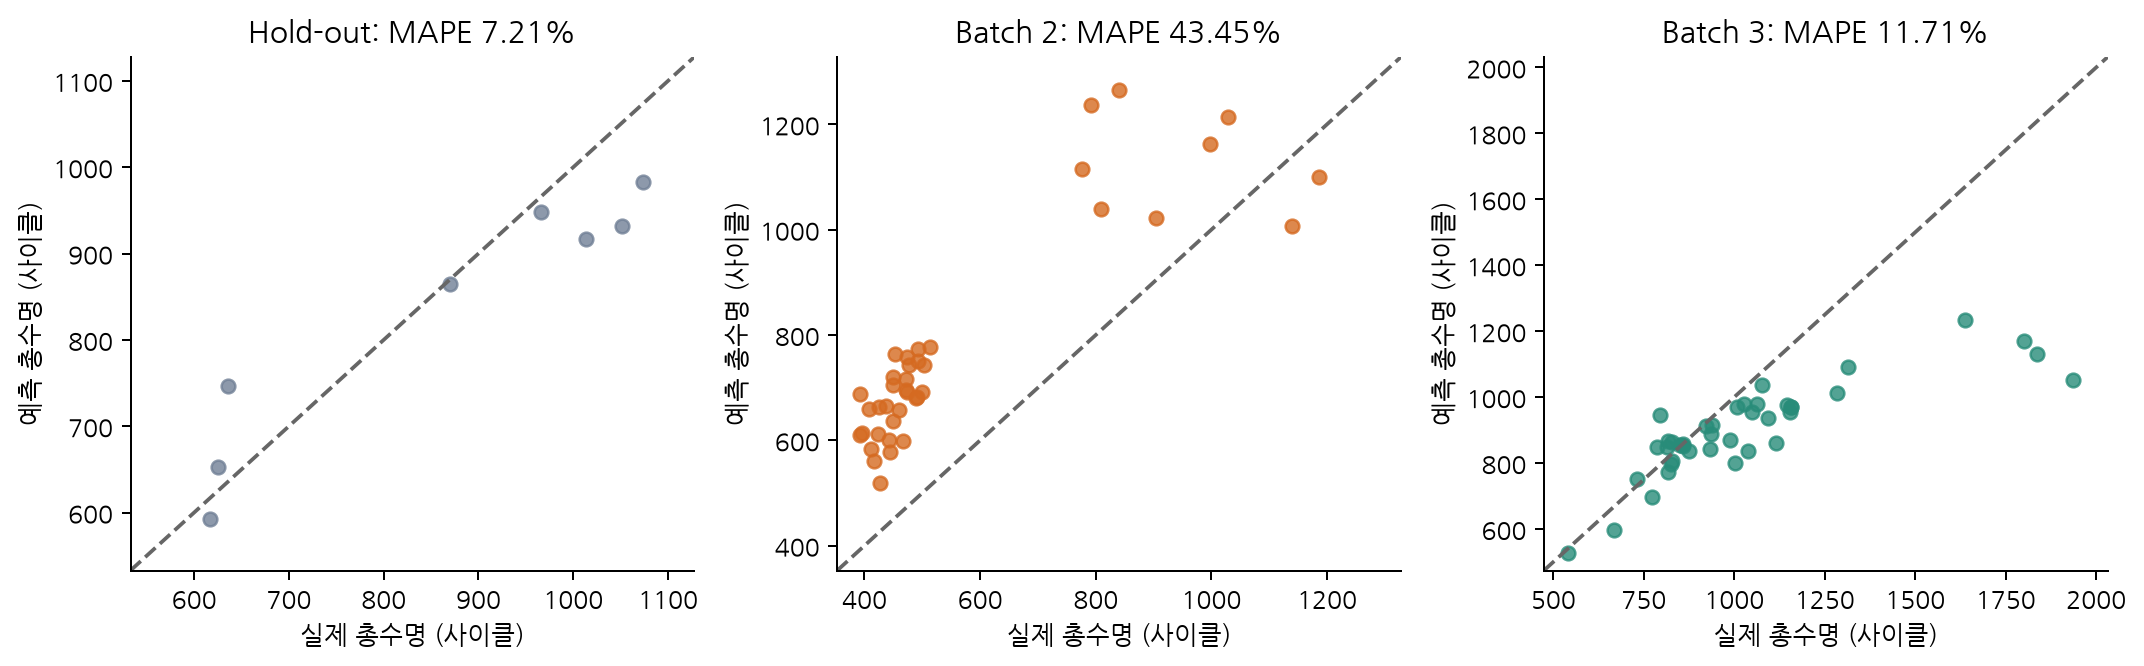

In [4]:
import joblib
from src.train import metrics
from src.preprocess import load_features
model = joblib.load(ROOT/'models/final_model.joblib')
f,_ = load_features(ROOT);by_id=f.set_index('cell_id')
pred = pd.read_csv(ROOT/'results/predictions.csv')
pred = pred.loc[pred.model == selection['selected_model']]
rows=[]
for subset,part in pred.groupby('subset'):
    replay=model['model'].predict(by_id.loc[part.cell_id,model['features']])
    np.testing.assert_allclose(replay,part.predicted,rtol=1e-10,atol=1e-8)
    rows.append({'구분':subset,**metrics(part.actual,replay)})
display(pd.DataFrame(rows))
show_plot('11_model_parity')

## 과제 요구 성능표와 Gap
MAPE는 %이고 Gap은 %p다. 양수 Gap은 뒤 평가의 오차 증가를 뜻한다.

In [5]:
display(pd.read_csv(ROOT/'results/model_performance.csv'))
display(pd.read_csv(ROOT/'results/mape_bootstrap.csv'))

,구분,MAPE (%) 또는 Gap (%p),비고
0,Train (Batch 1 CV),7.7197,"정책 그룹 5-fold, 평균 ± 표준편차 7.720 ± 2.564%"
1,Valid (Batch 1 Hold-out),7.2069,개발 데이터와 정책이 겹치지 않는 8개 셀
2,Test (Batch 2),43.4545,"과제 지정 2018-02-20, 39개 셀"
3,Gap (Train-Valid),-0.5128,Valid − CV; 양수이면 내부 검증 오차 증가
4,Gap (Valid-Test),36.2476,Batch 2 − Valid; 양수이면 외부 평가 오차 증가
5,Gap (Target-Test),34.3545,Batch 2 − 9.1; 서로 다른 코호트·분리 조건의 참고 비교
6,Test (Batch 3),11.7116,"추가 평가, 2018-04-12, 40개 셀"
7,Gap (Batch2-Batch3),-31.7428,Batch 3 − Batch 2; 양수이면 Batch 3 오차가 더 큼
8,"Gap (Target-Test, Batch 3)",2.6116,Batch 3 − 9.1; 논문 목표와의 참고 비교


,subset,n_cells,n_policy_groups,MAPE (%),bootstrap_2.5%,bootstrap_97.5%,method
0,Batch 2,39,12,43.4545,36.0982,49.8706,2000 policy-cluster bootstrap resamples; fixed...
1,Batch 3,40,8,11.7116,8.5178,15.9145,2000 policy-cluster bootstrap resamples; fixed...
2,Hold-out,8,5,7.2069,5.3695,9.0619,2000 policy-cluster bootstrap resamples; fixed...


## 단일 피처 기준과 비교
Batch 2에서는 CV로 고른 최종 모델보다 단일 피처 기준이 낫다. 이 실패도 결과에 포함한다.

,model,subset,n,MAPE (%),MAE (cycles),RMSE (cycles),R2,Bias (cycles),overprediction_count,predicted_life_le_100_count
0,ElasticNet / discharge,Hold-out,8,7.2069,61.6310,75.5113,0.8381,-27.0464,2,0
1,ElasticNet / discharge,Batch 2,39,43.4545,222.3940,235.1805,-0.1497,211.1214,37,0
2,ElasticNet / discharge,Batch 3,40,11.7116,148.5950,243.3574,0.3622,-130.2708,8,0
3,Dummy median,Hold-out,8,22.5612,199.7500,216.0712,-0.3259,-107.1250,3,0
4,Dummy median,Batch 2,39,55.3762,272.3974,286.1363,-0.7019,183.7564,30,0
5,Dummy median,Batch 3,40,24.7452,297.9750,415.5218,-0.8595,-282.5000,3,0
6,Variance linear,Hold-out,8,9.2919,82.6649,95.1722,0.7428,-47.2846,3,0
7,Variance linear,Batch 2,39,29.8954,147.3409,162.5674,0.4506,136.8011,35,0
8,Variance linear,Batch 3,40,11.5971,138.3325,227.1478,0.4443,-66.7357,16,0


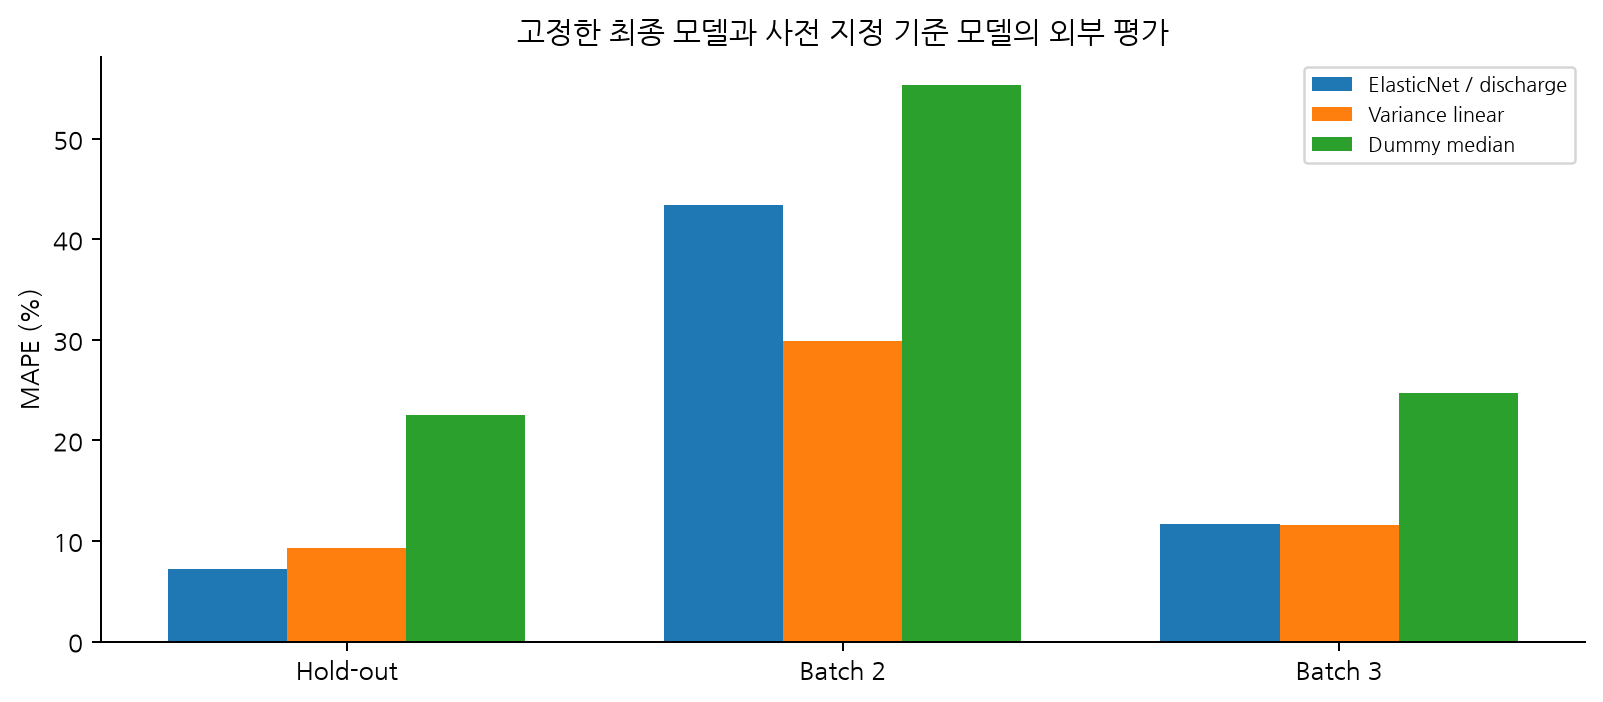

In [6]:
display(pd.read_csv(ROOT/'results/evaluation_metrics.csv'))
show_plot('14_baseline_comparison')

## 오류 사례, 피처 이동과 계수
B2 과대 예측·B3 장수명 과소 예측을 구분한다. 물리 해석은 인과 효과가 아닌 검증할 가설이다.

,cell_id,batch,charging_policy,actual,model,subset,fold,predicted,error_cycles,absolute_percentage_error
0,b2c6,2,3.6C(9%)-5C,393.0,ElasticNet / discharge,Batch 2,NaN,688.4931,295.4931,75.1891
1,b2c29,2,5.2C(58%)-4C,452.0,ElasticNet / discharge,Batch 2,NaN,763.1535,311.1535,68.8393
2,b2c21,2,6C(60%)-3C,408.0,ElasticNet / discharge,Batch 2,NaN,659.1947,251.1947,61.5673
3,b2c18,2,5.2C(50%)-4.25C,449.0,ElasticNet / discharge,Batch 2,NaN,719.8153,270.8153,60.3152
4,b2c42,2,5.2C(50%)-4.25C,474.0,ElasticNet / discharge,Batch 2,NaN,757.6782,283.6782,59.8477
5,b2c10,2,4.8C(80%)-4.8C,492.0,ElasticNet / discharge,Batch 2,NaN,773.1696,281.1696,57.1483


,subset,dimension,group,n,MAPE (%),MAE (cycles),RMSE (cycles),R2,Bias (cycles),overprediction_count,predicted_life_le_100_count
0,CV OOF,life_range,500–1000,26,7.1436,51.9285,62.0466,0.6555,15.9440,17,0
1,CV OOF,life_range,>1000,2,13.9819,144.0275,149.3958,-64.2129,-144.0275,0,0
2,CV OOF,seen_training_policy,False,28,7.6320,58.5070,71.8959,0.6743,4.5175,17,0
3,CV OOF,outside_training_target_range,False,25,6.6455,53.1775,66.7504,0.5761,1.0563,15,0
4,CV OOF,outside_training_target_range,True,3,15.8528,102.9197,105.4235,0.8062,33.3605,2,0
5,Hold-out,life_range,500–1000,5,5.6733,37.3641,52.7620,0.8700,17.9712,2,0
6,Hold-out,life_range,>1000,3,9.7628,102.0757,102.7887,-16.2953,-102.0757,0,0
7,Hold-out,seen_training_policy,False,8,7.2069,61.6310,75.5113,0.8381,-27.0464,2,0
8,Hold-out,outside_training_target_range,False,7,7.0315,57.4948,73.1048,0.8357,-17.9696,2,0
9,Hold-out,outside_training_target_range,True,1,8.4343,90.5843,90.5843,NaN,-90.5843,0,0


,feature,standardized_log10_coefficient,coefficient_per_original_unit
0,delta_q_logvar,-0.0556,-0.2568
1,delta_q_min,0.0056,1.3280
2,QD_2,0.0244,2.8408
3,QD_slope,0.0000,0.0000


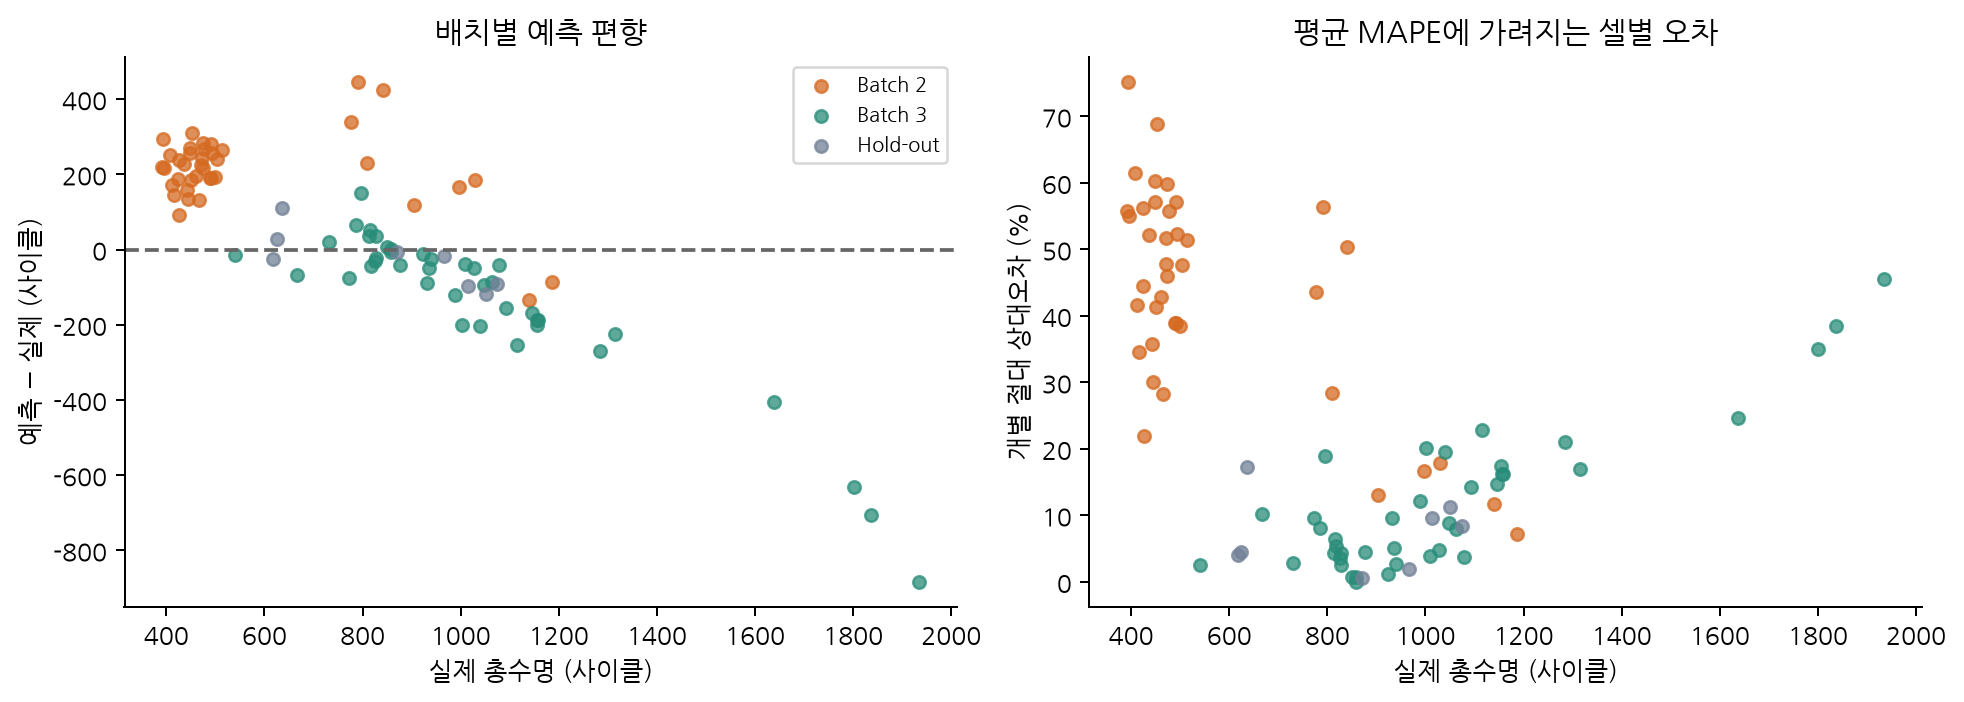

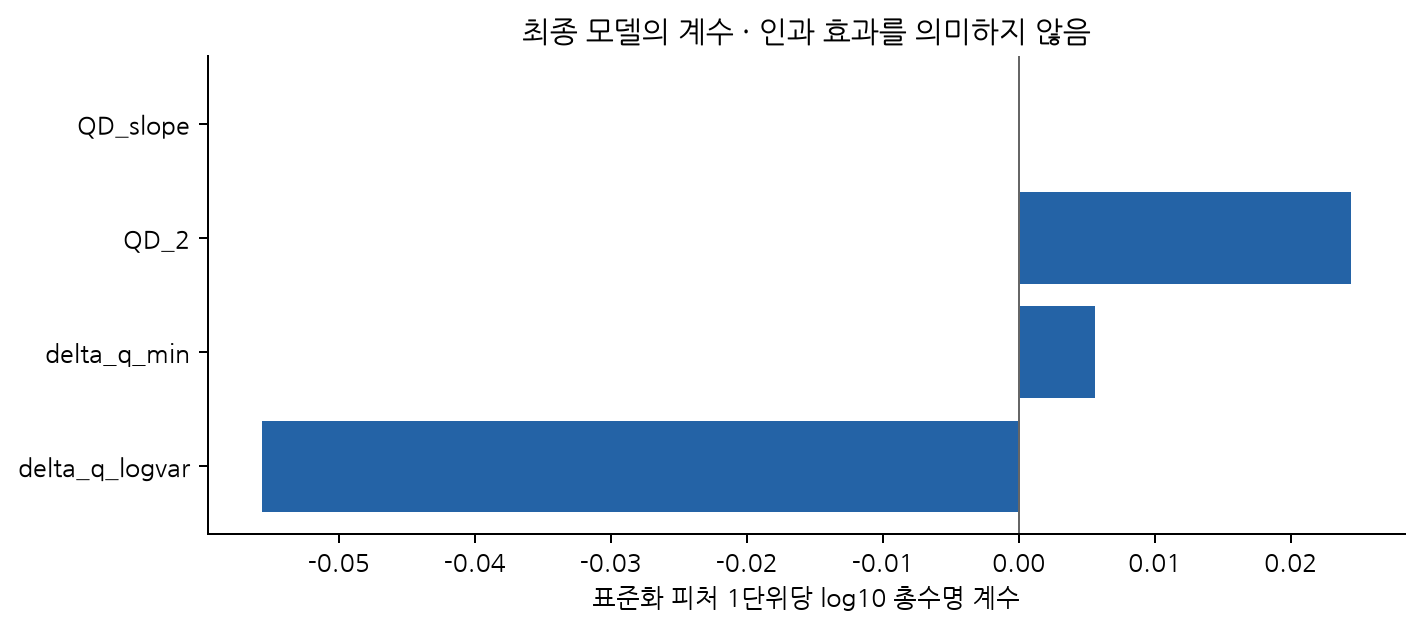

In [7]:
display(pd.read_csv(ROOT/'results/largest_errors.csv').head(6))
display(pd.read_csv(ROOT/'results/error_groups.csv'))
display(pd.read_csv(ROOT/'results/model_coefficients.csv'))
show_plot('12_model_errors')
show_plot('15_model_coefficients')

## 전기전자공학 시사점과 후기

In [8]:
text=(ROOT/'docs/DAY2_분석보고서.md').read_text()
start=text.index('## 10.');end=text.index('## 12.')
display(Markdown(text[start:end].replace('<!-- PAGEBREAK -->','')))

## 10. 전기전자공학과 ESS 운영 시사점

**BMS의 상태 추정:** 초기 용량이 크거나 SOH가 높다는 사실만으로 장수명을 보장할 수 없다. 용량·전압 곡선·저항·온도는 서로 다른 상태 정보를 제공한다. 총수명 예측, 현재 SOH, 출력 한계 SOP를 구분해야 한다.

**PCS의 충전 제어:** 전류 프로파일과 SOC 구간은 I²R 손실과 상태 응답에 연결된다. 이번 상관분석은 충전 전략 가설을 만드는 근거이며, 고속 충전의 인과 효과나 최적 정책을 입증하지 않는다. 실측 전류와 평균 저항의 ∫I²Rdt는 손실 대리값으로 실제 총발열 측정값과 구분했다.

**EMS의 유지보수 판단:** Batch 2에서 수명을 과대 예측한 결과는 교체 일정을 지나치게 늦출 수 있는 오차 방향을 보여 준다. 모델 출력은 점검 우선순위 검토에 활용하되 BMS의 전압·온도 보호 조건과 함께 판단해야 한다. 용량 기반 EOL 예측 오차를 화재 위험 예측 성능으로 해석할 수 없다.

**셀에서 팩으로의 확장:** 셀 평균만으로 팩 전체 수명을 판단하기 어렵다. 직렬 연결에서 약한 셀, 냉각 편차, 저항·용량 불균형과 밸런싱이 운전 한계에 영향을 준다. 실제 팩·ESS 데이터의 별도 검증이 필요하다.

**현장 적용 조건:** 실험실 고속 충전 데이터와 실제 ESS의 부분 충·방전, 휴지, 온도 변화, SOC 체류 및 달력 열화는 다르다. 현장에서 ΔQ(V)를 안정적으로 산출할 수 있는지, 센서 오차와 운전 범위 변화가 예측에 미치는 영향을 먼저 확인해야 한다.

### 이번 결과가 제시하는 판단 기준

내부 정확도뿐 아니라 외부 운전 조건, 과대·과소 예측의 방향, 센서 품질과 적용 범위를 함께 설명해야 한다. 유지보수 판단에 사용할 모델이라면 평균 오차가 낮은 것보다 어느 조건에서 실패하는지 아는 것이 중요하다.



## 11. 분석을 통해 느낀 점

이번 과제는 SKALA 수업에서 처음으로 전기전자공학 전공과 연결해 진행한 데이터 분석 과제라 특히 흥미로웠다. 전압·전류·용량·저항·온도처럼 전공에서 다루는 신호가 실제 배터리 수명 분석에 어떻게 활용되는지 직접 살펴볼 수 있었다. 전공 지식과 데이터 분석을 함께 사용하면서 공학 문제를 이해하는 또 다른 방법을 경험했다.

DAY 1에서는 ΔQ 분산과 수명의 강한 관계를 보고 예측에 유용할 것이라고 생각했다. 실제 모델을 평가하니 내부 CV와 hold-out에서는 오차가 작았지만, 지정 Batch 2에서는 오차가 크게 증가했다. 상관계수가 높다는 것과 새로운 조건에서 모델이 정확하다는 것은 별도로 확인해야 한다는 점을 배웠다.

초기 용량을 추가하면 내부 검증이 개선됐지만 외부 배치에서는 단일 피처 기준보다 오차가 커진 점도 인상적이었다. 물리적으로 의미 있는 변수라도 학습 데이터에서 관측한 관계가 다른 조건에서 그대로 유지되는 것은 아니었다. 계측값의 정의와 배치 조건을 확인하고, 피처를 늘리는 이유를 성능과 함께 검증하는 습관이 중요하다고 느꼈다.

전기전자공학 관점에서는 평균 오차뿐 아니라 오차 방향을 보는 일이 중요했다. 수명을 길게 예측하면 유지보수 판단이 늦어질 수 있고, 짧게 예측하면 불필요한 교체로 이어질 수 있다. 모델은 전기적 보호 제어를 대신하는 것이 아니라, 상태 추정과 점검 판단을 보완하는 도구로 이해해야 한다고 생각했다.

앞으로 SKALA 수업에서도 전공과 연결된 데이터를 분석할 기회가 더 많아졌으면 좋겠다. 배터리뿐 아니라 전력·에너지 분야의 다양한 데이터를 다루며, 전공 지식을 실제 문제에 적용하고 데이터로 판단하는 경험을 더 쌓고 싶다.

### 다음에 확인하고 싶은 것

절대 초기 용량과 변화 기반 피처의 배치 의존성을 비교하고, 저항·온도·운전 조건이 더 다양한 자료에서 전기적 등가회로와 데이터 기반 수명 모델을 함께 검증해 보고 싶다.



